#FUENTE:
##"Visión Artificial mediante Aprendizaje Automático con Tensorflow y Pytorch"
###[Web libro:] (https://alfaomegaeditor.com.ar/producto/vision-artificial-mediante-aprendizaje-automatico-con-tensorflow-y-pytorch/#/)

Parte 0: Generar feature map

In [1]:
#*****************************************************
# Autor: Jaime Duque
# Adaptación: Anahí Romo
#*****************************************************
# Generamos un feature map del primer frame del vídeo 1

import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"
# Ignoramos los mensajes de aviso de CUDA
os.environ['TF_CPP_MIN_LOG_LEVEL'] = "2"

In [ ]:
"""
# Utilizamos el dataset DCSASS
# https://www.kaggle.com/datasets/mateohervas/dcsass-dataset?resource=download
# https://github.com/Kaggle/kagglehub

#OPCIÓN 1
# Descargamos directamente desde Kaggle -> OJO QUE VA A UN DIRECTORIO PROPIO
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mateohervas/dcsass-dataset")

print("Path to dataset files:", path)
"""

In [2]:
# VALIDAR EL USUARIO DE KAGGLE

from google.colab import files
from IPython.display import clear_output

files.upload() # subir archivo con apikey de kaggle propio: kaggle.json
clear_output() # no muestra contenido del apikey


In [3]:
!ls

kaggle.json  sample_data


# Utilizamos el dataset DCSASS

In [4]:
# URL del dataset: https://www.kaggle.com/datasets/mateohervas/dcsass-dataset?resource=download

#OPCIÓN 2: descargamos todo el dataset al /content donde estamos parados
# Gracias a https://platzi.com/tutoriales/1794-pandas/6926-usando-la-api-de-kaggle-con-google-colab-para-carga-y-descarga-de-datasets/

!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets list

ref                                                         title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  -----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
jayaantanaath/student-habits-vs-academic-performance        Student Habits vs Academic Performance                19512  2025-04-12 10:49:08.663000          14694        265  1.0              
khushikyad001/screen-time-and-app-usage-dataset-iosandroid  Screen Time and App Usage Dataset (iOS/Android)      157038  2025-04-19 13:23:41.067000           1414         23  1.0              
fatemehmohammadinia/heart-attack-dataset-tarik-a-rashid     Heart Attack Dataset                                  16250  2025-04-30 21:58:22.740000           2081         38  1.0              
nikolasgegenava/sneakers-classifica

In [5]:
!kaggle datasets download -d mateohervas/dcsass-dataset  # descarga como .zip

Dataset URL: https://www.kaggle.com/datasets/mateohervas/dcsass-dataset
License(s): CC-BY-NC-SA-4.0


In [6]:
!ls

dcsass-dataset.zip  kaggle.json  sample_data


In [17]:
!unzip dcsass-dataset.zip -d VIDEOS  # Descomprimir en el directorio VIDEOS

Se truncaron las últimas líneas 5000 del resultado de transmisión.
  inflating: VIDEOS/dcsass dataset/DCSASS Dataset/Robbery/Robbery142_x264.mp4/Robbery142_x264_30.mp4  
  inflating: VIDEOS/dcsass dataset/DCSASS Dataset/Robbery/Robbery142_x264.mp4/Robbery142_x264_31.mp4  
  inflating: VIDEOS/dcsass dataset/DCSASS Dataset/Robbery/Robbery142_x264.mp4/Robbery142_x264_4.mp4  
  inflating: VIDEOS/dcsass dataset/DCSASS Dataset/Robbery/Robbery142_x264.mp4/Robbery142_x264_5.mp4  
  inflating: VIDEOS/dcsass dataset/DCSASS Dataset/Robbery/Robbery142_x264.mp4/Robbery142_x264_6.mp4  
  inflating: VIDEOS/dcsass dataset/DCSASS Dataset/Robbery/Robbery142_x264.mp4/Robbery142_x264_7.mp4  
  inflating: VIDEOS/dcsass dataset/DCSASS Dataset/Robbery/Robbery142_x264.mp4/Robbery142_x264_8.mp4  
  inflating: VIDEOS/dcsass dataset/DCSASS Dataset/Robbery/Robbery142_x264.mp4/Robbery142_x264_9.mp4  
  inflating: VIDEOS/dcsass dataset/DCSASS Dataset/Robbery/Robbery145_x264.mp4/Robbery145_x264_0.mp4  
  inflating: 

In [18]:
!ls

DCASS  dcsass-dataset.zip  kaggle.json	sample_data  VIDEOS


# SUGERENCIA IMPORTANTE: para acceder correctamente a los directorios,
# COPIAR LA RUTA DE ACCESO desde el árbol de directorios a la izquierda

In [36]:
# OPCIÓN 3: MONTAR GOOGLE DRIVE Y DESCARGAR EL DATASET DESDE AHÍ

# GRACIAS A https://colab.research.google.com/gist/redpanda-ai/8d5498ec5baf646a66a8e6de20f9e0f8/loading_files_from_google_drive_into_colab.ipynb
# con esto monta la unidad de Drive

from google.colab import drive
drive.mount('/content/drive')
data_dir= '/content/drive/VIDEOS'

Mounted at /content/drive


In [40]:
import zipfile
# Descargaremos directo desde Drive el dataset zipeado

videos='/content/drive/MyDrive/VIDEOS/DCSASS_Dataset.zip'

with zipfile.ZipFile(videos) as my_zip:
  my_zip.extractall(path='/content/')

In [ ]:
# desmontar Drive después de la descarga
drive.flush_and_unmount()

In [41]:
!ls

DCASS		dcsass-dataset.zip  kaggle.json  VIDEOS
DCSASS_Dataset	drive		    sample_data


In [42]:
# Importaciones
import os
import os.path
import numpy as np
import random
from sklearn.model_selection import train_test_split
# Librerías de Tensorflow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
# Cargamos Matplotlib para representar gráficamente el entrenamiento
import matplotlib.pyplot as plt
import cv2

In [61]:
# Generamos un feature map del primer frame del vídeo 1

DIRECTORIO_VIDEO_1FRAME= '/content/DCSASS_Dataset/Arrest/Arrest028_x264.mp4/Arrest028_x264_8.mp4'


In [62]:
DIRECTORIO_VIDEO_1FRAME

'/content/DCSASS_Dataset/Arrest/Arrest028_x264.mp4/Arrest028_x264_8.mp4'

In [56]:
!ls /content/DCSASS_Dataset/Arrest/Arrest028_x264.mp4/

Arrest028_x264_0.mp4   Arrest028_x264_1.mp4   Arrest028_x264_2.mp4
Arrest028_x264_10.mp4  Arrest028_x264_20.mp4  Arrest028_x264_30.mp4
Arrest028_x264_11.mp4  Arrest028_x264_21.mp4  Arrest028_x264_31.mp4
Arrest028_x264_12.mp4  Arrest028_x264_22.mp4  Arrest028_x264_3.mp4
Arrest028_x264_13.mp4  Arrest028_x264_23.mp4  Arrest028_x264_4.mp4
Arrest028_x264_14.mp4  Arrest028_x264_24.mp4  Arrest028_x264_5.mp4
Arrest028_x264_15.mp4  Arrest028_x264_25.mp4  Arrest028_x264_6.mp4
Arrest028_x264_16.mp4  Arrest028_x264_26.mp4  Arrest028_x264_7.mp4
Arrest028_x264_17.mp4  Arrest028_x264_27.mp4  Arrest028_x264_8.mp4
Arrest028_x264_18.mp4  Arrest028_x264_28.mp4  Arrest028_x264_9.mp4
Arrest028_x264_19.mp4  Arrest028_x264_29.mp4


In [49]:
# Paso 1. Iniciamos nuestro modelo (orientado a extracción de feature maps)
image_shape=(224, 224, 3)
input_tensor = Input(image_shape)
modelo = ResNet50(input_tensor=input_tensor,
                  weights="imagenet",
                  include_top=False)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [50]:
# Hacemos un resumen de las capas convolucionales y sus dimensiones
for i in range(len(modelo.layers)):
    layer = modelo.layers[i]
    # Nos centramos en capas de convolución
    if "_conv" not in layer.name:
        continue
    print(i, layer.name, layer.output.shape)

# Creamos un nuevo modelo cuya salida serán todas las capas convolucionales
layer_outputs = [layer.output for layer in modelo.layers if "_conv" in layer.name]
modelo = Model(inputs=modelo.inputs, outputs=layer_outputs)

2 conv1_conv (None, 112, 112, 64)
7 conv2_block1_1_conv (None, 56, 56, 64)
10 conv2_block1_2_conv (None, 56, 56, 64)
13 conv2_block1_0_conv (None, 56, 56, 256)
14 conv2_block1_3_conv (None, 56, 56, 256)
19 conv2_block2_1_conv (None, 56, 56, 64)
22 conv2_block2_2_conv (None, 56, 56, 64)
25 conv2_block2_3_conv (None, 56, 56, 256)
29 conv2_block3_1_conv (None, 56, 56, 64)
32 conv2_block3_2_conv (None, 56, 56, 64)
35 conv2_block3_3_conv (None, 56, 56, 256)
39 conv3_block1_1_conv (None, 28, 28, 128)
42 conv3_block1_2_conv (None, 28, 28, 128)
45 conv3_block1_0_conv (None, 28, 28, 512)
46 conv3_block1_3_conv (None, 28, 28, 512)
51 conv3_block2_1_conv (None, 28, 28, 128)
54 conv3_block2_2_conv (None, 28, 28, 128)
57 conv3_block2_3_conv (None, 28, 28, 512)
61 conv3_block3_1_conv (None, 28, 28, 128)
64 conv3_block3_2_conv (None, 28, 28, 128)
67 conv3_block3_3_conv (None, 28, 28, 512)
71 conv3_block4_1_conv (None, 28, 28, 128)
74 conv3_block4_2_conv (None, 28, 28, 128)
77 conv3_block4_3_conv (Non

In [63]:
# Paso 2. Procesamos el primer frame de un vídeo como ejemplo
cap = cv2.VideoCapture(DIRECTORIO_VIDEO_1FRAME)


In [64]:
cap.isOpened()

True

In [65]:
# Leemos el primer frame del vídeo
while (cap.isOpened()):
    ret, frame = cap.read()
    if ret == True:
        # Grabamos la imagen
        cv2.imwrite('imagenOrigenFeatMap.png', frame)
        # Reducir a 224x224 (Tamaño utilizado por ResNet-50)
        x = cv2.resize(frame, (224, 224), interpolation = cv2.INTER_AREA)
        # Convertir BGR (OpenCV) a RGB
        x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
        # Pasamos a array y preprocesamos
        x = image.img_to_array(x)
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)
        feature_maps = modelo.predict(x, verbose="0")
        break

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [66]:
type(x)

numpy.ndarray

In [67]:
x.shape

(1, 224, 224, 3)

In [ ]:
x

array([[[[-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         ...,
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ]],

        [[-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         ...,
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ]],

        [[-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         ...,
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ]],

        ...,

        [[-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         ...,
         [-103.939, -116.779, -123.68 ],
         [-103.939, -1

In [68]:
type(feature_maps)

list

In [69]:
len(feature_maps)

53

In [ ]:
feature_maps

[array([[[[-2.17742722e+02, -2.58444309e+00, -5.68553505e+01, ...,
           -6.62463951e+00,  3.83288116e+01, -6.21477547e+01],
          [ 6.22606163e+01, -7.52661180e+00, -6.97279358e+01, ...,
           -1.30081682e+01,  3.90965881e+01,  3.20932794e+00],
          [ 2.95053940e+01, -8.95536995e+00, -7.36200485e+01, ...,
           -1.05802402e+01,  3.59187088e+01,  1.35213482e+00],
          ...,
          [ 2.95053940e+01, -8.95536995e+00, -7.36200485e+01, ...,
           -1.05802402e+01,  3.59187088e+01,  1.35213482e+00],
          [ 2.95053940e+01, -8.95536995e+00, -7.36200485e+01, ...,
           -1.05802402e+01,  3.59187088e+01,  1.35213482e+00],
          [ 2.09682159e+02, -5.76074791e+00, -3.91837540e+01, ...,
           -2.46114693e+01,  1.78734150e+01,  7.55914307e+01]],
 
         [[-2.96909973e+02, -1.61978257e+00, -5.42199135e+01, ...,
           -2.32972984e+01,  1.96703224e+01,  6.90462923e+00],
          [-4.94817123e+01, -1.01168175e+01, -5.02092476e+01, ...,
     

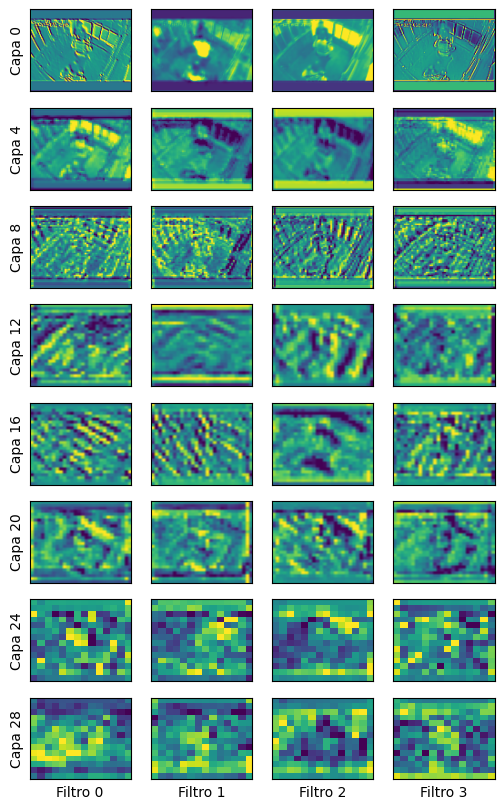

In [70]:
# Paso 3. Mostramos en 8 filas los mapas de features de
# las 8 primeras capas convolucionales. Para cada una,
# mostramos 4 feature maps.
filas = 8
columnas = 4

f, axes = plt.subplots(filas, columnas, figsize=(6, 10))

for f in range(filas):
    feature_maps_capa = feature_maps[4*f]
    for c in range(columnas):
        # Especificar subplot
        ax = plt.subplot(filas, columnas, f * columnas + c + 1)
        ax.set_xticks([])
        ax.set_yticks([])
        if c == 0:
            ax.set_ylabel("Capa " + str(4*f))
        if f == filas-1:
            ax.set_xlabel("Filtro " + str(c))
        # Obtenemos la imagen de uno de los filtros aplicados en la capa
        feature_image = feature_maps_capa[0, :, :, c]
        # Normalizamos la imagen para que se visualice mejor
        feature_image-= feature_image.mean()
        feature_image/= feature_image.std ()
        feature_image*=  64
        feature_image+= 128
        feature_image= np.clip(feature_image, 0, 255).astype("uint8")
        plt.imshow(feature_image, aspect="auto")
# Mostrar los mapas
plt.savefig("featureMaps.pdf", format="pdf")
plt.show()

In [71]:
!ls

DCASS		    drive		     kaggle.json
DCSASS_Dataset	    featureMaps.pdf	     sample_data
dcsass-dataset.zip  imagenOrigenFeatMap.png  VIDEOS


In [72]:
# Liberamos el objeto de lectura de vídeo
cap.release()

In [73]:
cap.isOpened()

False

Parte 1: Obtener features

In [74]:
CLASES_A_CONSIDERAR = ["Arrest", "Explosion", "RoadAccidents"]
DIRECTORIO_VIDEOS_DCSASS="/content/DCSASS_Dataset"  #reemplazar x el que uds deseen
DIRECTORIO_SALIDA_FEATURES= "/content/FEAT"  #reemplazar x el que uds deseen

# Creamos directorio de salida si no existe
if not os.path.exists(DIRECTORIO_SALIDA_FEATURES):
    os.mkdir(DIRECTORIO_SALIDA_FEATURES)

In [75]:
!ls

DCASS		    drive	     imagenOrigenFeatMap.png  VIDEOS
DCSASS_Dataset	    FEAT	     kaggle.json
dcsass-dataset.zip  featureMaps.pdf  sample_data


In [76]:
class Extractor():
    # Definimos modelo
    def __init__(self, image_shape=(224, 224, 3)):
        input_tensor = Input(image_shape)
        self.model = ResNet50(
            input_tensor=input_tensor,
            weights="imagenet",
            include_top=False,
            pooling="avg")
    # Creamos extractor de features a partir de una imagen
    def extract_image(self, img):
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)
        features = self.model.predict(x, verbose="0")
        return features[0]


In [77]:
# Iniciamos nuestro modelo
model = Extractor()

In [78]:
# DEMORÓ UNAS 5 HORAS

for accion in sorted(os.listdir(DIRECTORIO_VIDEOS_DCSASS)):
    # Tratamos las clases especificadas
    if accion not in CLASES_A_CONSIDERAR:
        continue
    print("Procesando accion: " + accion)

    # Obtenemos la clase
    clase = CLASES_A_CONSIDERAR.index(accion)

    # Recorremos los vídeos de las acciones
    for nombre_video in sorted(os.listdir(os.path.join(DIRECTORIO_VIDEOS_DCSASS, accion))):
        # Verificamos si no hemos procesado el fichero anteriormente
        fichero_salida = os.path.join(DIRECTORIO_SALIDA_FEATURES, nombre_video.replace(".mp4", ".npy"))
        if os.path.exists(fichero_salida):
            continue

        print("Procesando vídeo: " + nombre_video)
        # En datos iremos grabando todos los datos de features
        datos = []
        nframe = 0
        # Recorremos las secuencias del vídeo
        # Por su numeración y para evitar 0, 1, 10, 11, 2, 20, etc
        # recorremos generando nosotros el número
        # 1000 secuencias como máximo
        for numero in range(1000):
            secuencia = nombre_video.replace(".mp4", "_" + str(numero) + ".mp4")
            ruta_secuencia = os.path.join(DIRECTORIO_VIDEOS_DCSASS, accion, nombre_video, secuencia)
            if not os.path.exists(ruta_secuencia):
                break

            print("Procesando secuencia: " + secuencia)
            # Abrimos secuencia
            cap = cv2.VideoCapture(ruta_secuencia)

            # Leemos el vídeo frame a frame
            while (cap.isOpened()):
                ret, frame = cap.read()
                if ret == True:
                    # Reducir a 224x224 (Tamaño utilizado por ResNet-50)
                    resized = cv2.resize(frame, (224, 224), interpolation = cv2.INTER_AREA)
                    # Convertir BGR (OpenCV) a RGB
                    fr2 = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
                    features = model.extract_image(fr2)
                    datos.append([accion, clase, nombre_video, nframe, features])
                    nframe += 1
                else:
                    break
            # Liberamos el objeto de lectura de vídeo
            cap.release()
        # Escribimos el vídeo asociado de features
        np.save(fichero_salida, np.asanyarray(datos, dtype="object"))

Procesando accion: Arrest
Procesando vídeo: Arrest001_x264.mp4
Procesando secuencia: Arrest001_x264_0.mp4


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_175']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Procesando secuencia: Arrest001_x264_1.mp4
Procesando secuencia: Arrest001_x264_2.mp4
Procesando secuencia: Arrest001_x264_3.mp4
Procesando secuencia: Arrest001_x264_4.mp4
Procesando secuencia: Arrest001_x264_5.mp4
Procesando secuencia: Arrest001_x264_6.mp4
Procesando secuencia: Arrest001_x264_7.mp4
Procesando secuencia: Arrest001_x264_8.mp4
Procesando secuencia: Arrest001_x264_9.mp4
Procesando secuencia: Arrest001_x264_10.mp4
Procesando secuencia: Arrest001_x264_11.mp4
Procesando secuencia: Arrest001_x264_12.mp4
Procesando secuencia: Arrest001_x264_13.mp4
Procesando secuencia: Arrest001_x264_14.mp4
Procesando secuencia: Arrest001_x264_15.mp4
Procesando secuencia: Arrest001_x264_16.mp4
Procesando secuencia: Arrest001_x264_17.mp4
Procesando secuencia: Arrest001_x264_18.mp4
Procesando secuencia: Arrest001_x264_19.mp4
Procesando secuencia: Arrest001_x264_20.mp4
Procesando secuencia: Arrest001_x264_21.mp4
Procesando secuencia: Arrest001_x264_22.mp4
Procesando secuencia: Arrest001_x264_23.m

In [80]:
import shutil
videos_npy = shutil.make_archive('features_arr_exp_road', 'zip','/content/FEAT')

In [81]:
files.download("features_arr_exp_road.zip") # descargamos los archivos con los features en .npy

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [82]:
datos

[['RoadAccidents',
  2,
  'RoadAccidents150_x264.mp4',
  0,
  array([0.12366997, 0.4493818 , 0.24940893, ..., 0.4519925 , 0.37306002,
         0.49614185], dtype=float32)],
 ['RoadAccidents',
  2,
  'RoadAccidents150_x264.mp4',
  1,
  array([0.11578984, 0.47784883, 0.24583855, ..., 0.5151958 , 0.3721432 ,
         0.4816559 ], dtype=float32)],
 ['RoadAccidents',
  2,
  'RoadAccidents150_x264.mp4',
  2,
  array([0.12060931, 0.46895108, 0.25809443, ..., 0.48696813, 0.33481708,
         0.4696848 ], dtype=float32)],
 ['RoadAccidents',
  2,
  'RoadAccidents150_x264.mp4',
  3,
  array([0.11303847, 0.46936256, 0.30660132, ..., 0.5067682 , 0.37241074,
         0.51254755], dtype=float32)],
 ['RoadAccidents',
  2,
  'RoadAccidents150_x264.mp4',
  4,
  array([0.12410526, 0.4326911 , 0.31144223, ..., 0.5252437 , 0.33649862,
         0.4812072 ], dtype=float32)],
 ['RoadAccidents',
  2,
  'RoadAccidents150_x264.mp4',
  5,
  array([0.11819752, 0.40721127, 0.37364137, ..., 0.5396734 , 0.37372106,
 

PARTE 2: Entrenar features

In [83]:
# A partir de las features obtenidas en el paso anterior,
# entrenamos un modelo de reconocimiento de acciones utilizando LSTM
# con diferente tamaño de ventana

TAM_BATCH = 8
NUM_EPOCAS = 10
NUM_CLASES = 3

In [84]:
# Paso 1. Para cada vídeo, hay un fichero de features
# Cargamos todos y los unificamos en memoria
# La estructura es:
#   - Nombre de clase
#   - Valor de clase
#   - Nombre de fichero
#   - Número de frame
#   - Vector de features (2048 elementos)
features = []

for fichero in sorted(os.listdir(DIRECTORIO_SALIDA_FEATURES)):
    if fichero.endswith(".npy"):
        datos = np.load(os.path.join(DIRECTORIO_SALIDA_FEATURES, fichero), allow_pickle=True)
        for v in datos:
            features.append(v)
print("Número de frames: ", len(features))

Número de frames:  187200


In [85]:
# Paso 2. Buscamos los diferentes vídeos que aparecen
# En el entrenamiento, cada vídeo representará una
# entrada al modelo
nombre_ficheros = []
frames_por_video = {}
for f in features:
    if f[2] not in nombre_ficheros:
        nombre_ficheros.append(f[2])
        frames_por_video[f[2]] = 1
    else:
        frames_por_video[f[2]] += 1
print("Lista de ficheros: ", nombre_ficheros)
print("Frames por vídeo: ", frames_por_video)

Lista de ficheros:  ['Arrest001_x264.mp4', 'Arrest002_x264.mp4', 'Arrest003_x264.mp4', 'Arrest004_x264.mp4', 'Arrest005_x264.mp4', 'Arrest006_x264.mp4', 'Arrest009_x264.mp4', 'Arrest011_x264.mp4', 'Arrest013_x264.mp4', 'Arrest014_x264.mp4', 'Arrest017_x264.mp4', 'Arrest019_x264.mp4', 'Arrest022_x264.mp4', 'Arrest023_x264.mp4', 'Arrest024_x264.mp4', 'Arrest025_x264.mp4', 'Arrest028_x264.mp4', 'Arrest031_x264.mp4', 'Arrest032_x264.mp4', 'Arrest036_x264.mp4', 'Arrest037_x264.mp4', 'Arrest038_x264.mp4', 'Arrest040_x264.mp4', 'Arrest041_x264.mp4', 'Arrest042_x264.mp4', 'Arrest048_x264.mp4', 'Explosion004_x264.mp4', 'Explosion006_x264.mp4', 'Explosion008_x264.mp4', 'Explosion009_x264.mp4', 'Explosion011_x264.mp4', 'Explosion013_x264.mp4', 'Explosion014_x264.mp4', 'Explosion017_x264.mp4', 'Explosion020_x264.mp4', 'Explosion022_x264.mp4', 'Explosion023_x264.mp4', 'Explosion024_x264.mp4', 'Explosion026_x264.mp4', 'Explosion028_x264.mp4', 'Explosion029_x264.mp4', 'Explosion032_x264.mp4', 'Explos

In [86]:
# Paso 3. Dividimos en Train y Test
train, test = train_test_split(nombre_ficheros, test_size=0.10, random_state=42)
train, val = train_test_split(train, test_size=0.20, random_state=42)

In [87]:
# Paso 4. Esta función devuelve X,Y para un vídeo dado por un nombre
# En X se devolverá una secuencia de features de longitud variable del
# tipo (num_frames, 2048). En Y se devolverá la clase asociada
# Nos quedamos con 960 frames por vídeo. En Tensorflow, los elementos de
# cada batch generado deben tener un tamaño de secuencia similar.
# Al seleccionar 960, los vídeos con más frames serán filtrados cogiendo
# uno de cada n frames para computar 960
MAX_FRAMES = 960
def getDatosVideo(nombreVideo):
    num_frames = frames_por_video[nombreVideo]
    incremento = num_frames // MAX_FRAMES
    x = []
    y = -1
    contador = 0
    for f in features:
        if f[2] == nombreVideo:
            contador += 1
            if contador == incremento:
                contador = 0
                x.append(f[4])
                y = f[1]
    return np.array(x), y

In [88]:
# Paso 5. Creamos un data generator que valdrá para train y val
# Cada vez que llamamos al generados, tenemos que obtener
# un batch de vídeos. En esta ocasión, lo generamos de
# forma aleatoria.
def generador(dataset):
    while True:
        x_data = []
        y_data = []
        for b in range(TAM_BATCH):
            nombre_video = random.choice(dataset)
            x, y = getDatosVideo(nombre_video)
            x_data.append(x)
            y_data.append(y)

        x_data = np.array(x_data, dtype=float)
        y_data = np.array(y_data)
        yield x_data, y_data

In [89]:
# Paso 6. Creamos un modelo
modelo = Sequential()
modelo.add(LSTM(256, return_sequences=False, input_shape=(None, 2048)))
modelo.add(Dense(64, activation="relu"))
modelo.add(Dense(NUM_CLASES, activation='softmax'))
modelo.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'], optimizer='adam')
print("Resumen del modelo: ")
modelo.summary()

Resumen del modelo: 


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 256)            │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,376,963 (9.07 MB)

 Trainable params: 2,376,963 (9.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 876ms/step - accuracy: 0.6679 - loss: 0.7669
Epoch 1: val_accuracy improved from -inf to 0.59375, saving model to /content/DCSASS_Dataset/modelo_DCSASS.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.6714 - loss: 0.7616 - val_accuracy: 0.5938 - val_loss: 0.9605
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 868ms/step - accuracy: 0.9441 - loss: 0.2256
Epoch 2: val_accuracy did not improve from 0.59375
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9447 - loss: 0.2238 - val_accuracy: 0.5938 - val_loss: 1.4020
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 886ms/step - accuracy: 0.9873 - loss: 0.0765
Epoch 3: val_accuracy did not improve from 0.59375
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9874 - loss: 0.0762 - val_accuracy: 0.4688 - val_loss: 1.0468
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 1.0000 - loss: 0.0239
Epoch 4: val_accuracy did not improve from 0.59375
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 1.0000 - loss: 0.0236 - val_accuracy: 0.4875 - val_loss: 1.9510
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 864ms/step - accuracy: 1.0000 - loss: 0.0033
Epoch 5: val_accuracy did not improve from 

30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.6000 - val_loss: 1.7657
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 862ms/step - accuracy: 1.0000 - loss: 6.1847e-04
Epoch 9: val_accuracy did not improve from 0.60000
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 1.0000 - loss: 6.1978e-04 - val_accuracy: 0.6000 - val_loss: 2.0981
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - accuracy: 1.0000 - loss: 6.1612e-04
Epoch 10: val_accuracy improved from 0.60000 to 0.63750, saving model to /content/DCSASS_Dataset/modelo_DCSASS.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 1.0000 - loss: 6.1451e-04 - val_accuracy: 0.6375 - val_loss: 2.0730


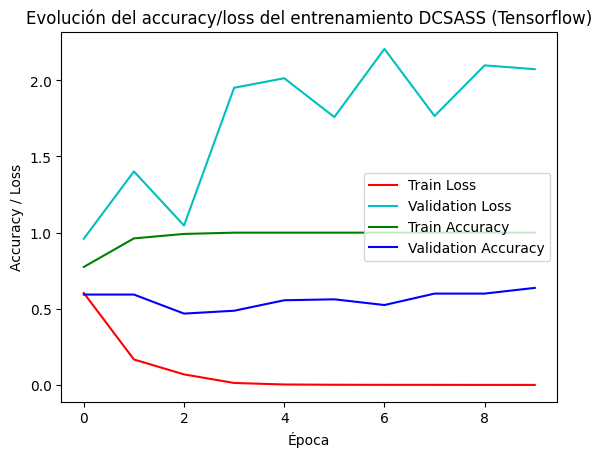

In [90]:
# Paso 7. Entrenamos el modelo
callbacks = [TensorBoard(log_dir=os.path.join(DIRECTORIO_VIDEOS_DCSASS, "logs")),
             ModelCheckpoint(filepath=os.path.join(DIRECTORIO_VIDEOS_DCSASS, "modelo_DCSASS.keras"),
                             monitor="val_accuracy",
                             verbose=2,
                             save_best_only=True,
                             mode='max')]

historia = modelo.fit(generador(train),
                      steps_per_epoch=30,
                      epochs=NUM_EPOCAS,
                      validation_data=generador(val),
                      validation_steps=20,
                      callbacks=callbacks,
                      verbose=1)

# Recargamos el modelo que mejor funcionaba con validación
modelo.load_weights(os.path.join(DIRECTORIO_VIDEOS_DCSASS, "modelo_DCSASS.keras"))

# Representamos gráficamente el entrenamiento mostrando la reducción del error
plt.plot(historia.history['loss'], 'r', label='Train Loss')
plt.plot(historia.history['val_loss'], 'c', label='Validation Loss')
plt.plot(historia.history['accuracy'], 'g', label='Train Accuracy')
plt.plot(historia.history['val_accuracy'], 'b', label='Validation Accuracy')
plt.ylabel('Accuracy / Loss')
plt.xlabel('Época')
plt.title("Evolución del accuracy/loss del entrenamiento DCSASS (Tensorflow)")
plt.legend(loc='center right')
plt.savefig("errorClasVideo.pdf", format="pdf")
plt.show()

In [91]:
# Paso 8. Evaluamos nuestro modelo
# Generamos primeramente los datos de test completos,
# y se los pasamos al método de evaluación
x_test = []
y_test = []
for v in test:
    x, y = getDatosVideo(v)
    x_test.append(x)
    y_test.append(y)
x_test = np.array(x_test, dtype=float)
y_test = np.array(y_test)
print(x_test.shape)
print(y_test.shape)

loss, acc = modelo.evaluate(x_test, y_test, verbose=1)
print("Test Accuracy: %.3f" % acc)

(13, 960, 2048)
(13,)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step - accuracy: 0.6154 - loss: 2.5365
Test Accuracy: 0.615
